In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
sys.path.append('/home/cosweeney/code/Fits/')

from fit_utils import bin_velocities_abs
from scipy.interpolate import RectBivariateSpline
from scipy.integrate import quad_vec
from scipy.stats import t, johnsonsu
from scipy.optimize import curve_fit
import pickle
import scipy
from tqdm import tqdm

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

# with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as pc:
#     print(pc.keys(), end=' ')

#     tag = np.array(pc['tag'])
#     orbit_mask = (tag == 0)
#     infall_mask = (tag == 1) 

#     hostmvir = np.array(pc['hostmvir'])
#     hostrvir = np.array(pc['hostrvir'])

#     #Massbins
#     print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
#     print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')

#     mini=hostmvir.min()
#     maxi=1.6e15#pc['hostmvir'].max()

#     #Choose Bins: Log-spaced bins between min and max
#     massbins = np.logspace( np.log10(mini), np.log10(maxi), 7+1)
#     mbins = np.delete(massbins, -2)
#     print('massbins:', mbins)

#     Rvirs=[]
#     Mvirs=[]
#     for i in range(len(mbins)-1):
#         mmask = (hostmvir>=mbins[i])&(hostmvir<=mbins[i+1])
#         orbi_M = hostmvir[mmask&orbit_mask]
#         orbi_R = hostrvir[mmask&orbit_mask]
#         print(mbins[i]/1e14, mbins[i+1]/1e14)

#         Rvirs.append(np.median(orbi_R))
#         Mvirs.append(np.median(orbi_M))
#     Rvirs=np.array(Rvirs)
#     Mvirs=np.array(Mvirs)

# # radial bins
# r_edges = np.linspace(4, 30, 26+1)
# r_cens = (r_edges[1:]+r_edges[:-1])/2.0

# zel_xhg = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_xhg.bin')
# xhg = h5.File("/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xihg_fit_fnl_2.h5")
# rxhg = np.array(xhg['rbins'])
# exhg = np.array(xhg['r_edges']) 
# xihg = np.array(xhg['xi'])

# path = "/spiff/cosweeney/simulations/MDPL2/data/models/"

# with open(path+'RBFint_xi_gals_update.pkl', 'rb') as f:
#     xi_RBF = pickle.load(f)

# with open(path+'RBFint_lam_gals_update.pkl', 'rb') as f: 
#     lam_RBF = pickle.load(f) 

<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.45648082e+14 2.65160344e+14 4.82738989e+14
 8.78852879e+14 1.60000000e+15]
$R_{vir}$ bin centers: [1.02778  1.249506 1.512833 1.835848 2.229771]
$M_{vir}$ bin centers: [1.0659e+14 1.9152e+14 3.3992e+14 6.0746e+14 1.0884e+15]
0.6777 74.71913613009617 74.71913613009617


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# bin MDPL2 data 

# Mass bin centers
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
rlos_ls = []
R_ls = []
M_ls = []

#for k, M in enumerate(Mvirs):
for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(vel_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}'][()]
            Mvir = hdf[f'Mvir/{str(k)}'][()]  

        mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

        vpeclos_ls.append(vpec[mask])
        vphyslos_ls.append(vphys[mask])
        rlos_ls.append(rel_rlos[mask])
        R_ls.append(rel_R[mask])
        M_ls.append(Mvir[mask])

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


KeyboardInterrupt: 

In [ ]:
# bin 'bin mass' model samples
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_15.hdf5'
#'/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_30.hdf5'

#vpeclos_bin  = []
vphyslos_bin = []
#rlos_bin = []
#R_bin = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        #if k == 0 and i < 16 or k > 0:
        with h5.File(samp_path, 'r') as hdf:
            #rel_R = hdf[f'R/{str(k)}/{str(i)}'][()]
            #rel_rlos = hdf[f'rlos/{str(k)}/{str(i)}'][()]
            #vpec = hdf[f'vpeclos/{str(k)}/{str(i)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}/{str(i+1)}'][()] # saved samples have an extra radial bin at r=4

        #vpeclos_bin.append(vpec)
        vphyslos_bin.append(vphys)
        #rlos_bin.append(rel_rlos)
        #R_bin.append(rel_R)
        # else:
        #     vpeclos_bin.append(np.array([]))
        #     vphyslos_bin.append(np.array([]))
        #     rlos_bin.append(np.array([]))
        #     R_bin.append(np.array([]))

In [4]:
# bin 'ind mass' model samples
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_ind_mass_samples_r_4_30.hdf5'

vpeclos_ind  = []
vphyslos_ind = []
rlos_ind = []
R_ind = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(samp_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}/{str(i)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}/{str(i)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}/{str(i)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}/{str(i)}'][()]

        vpeclos_ind.append(vpec)
        vphyslos_ind.append(vphys)
        rlos_ind.append(rel_rlos)
        R_ind.append(rel_R)

In [4]:
# compute histograms
bin_num = 50 

LOS_hists_MDPL2 = np.zeros((bin_num, len(Mvirs), len(r_cens)))
LOS_hists_bin = np.zeros((bin_num, len(Mvirs), len(r_cens)))
#LOS_hists_ind = np.zeros((bin_num, len(Mvirs), len(r_cens)))

vedges = np.linspace(-2500, 2500, bin_num+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])


for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k
        #samp_index = i + len(r_cens)*k


        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        hist_bin, v_edges = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
 #       hist_ind, v_edges = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists_MDPL2[:, k, i] = hist  
        LOS_hists_bin[:, k, i] = hist_bin  
  #      LOS_hists_ind[:, k, i] = hist_ind 

LOS_hists = [LOS_hists_MDPL2, LOS_hists_bin] #, LOS_hists_ind

In [5]:
# rescale by conversion factor for DESI estimates

# DESI BGS Estimation
from colossus.cosmology import cosmology

C = cosmology.setCosmology('planck13')
#C = cosmology.Cosmology

Area_deg = 1e4 #deg^2
Area_sr = Area_deg / (180.0/np.pi)**2 

z_1 = 0.1
z_2 = 0.4
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

V_MDPL2 = 1000**3 # h^-3 Mpc^3
#n_MDPL2 = 0.014 / cosmo.h**3 # num of galaxies in box / V_MDPL2 in Mpc^-3 
n_MDPL2 = 0.014 # num of galaxies in box / V_MDPL2 in h^3 Mpc^-3 

n_BGS = 1e-3 # h^3 Mpc^-3

N_MDPL2 = np.sum(LOS_hists_MDPL2) 
N_est = N_MDPL2 * V_DESI * n_BGS / V_MDPL2 / n_MDPL2 

conv_BGS = V_DESI * n_BGS / V_MDPL2 / n_MDPL2 


BGS_hists = [LOS_hist*conv_BGS for LOS_hist in LOS_hists]

# DESI LRG Estimation

z_1 = 0.4
z_2 = 0.8
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

n_LRG = 4.5e-4 # h^3 Mpc^-3 

N_MDPL2 = np.sum(LOS_hists_MDPL2) 
N_est = N_MDPL2 * V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

conv_LRG = V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

LRG_hists = [LOS_hist*conv_LRG for LOS_hist in LOS_hists]

In [6]:
# load grid of P(v|R, M)

path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_M_grid_R_5_15_gal.npy'
#'/spiff/cosweeney/simulations/MDPL2/data/Pvlos_M_grid_2Kmax_40rlos_500vpec_gal.npy'

P_vlos_grid = np.load(path)

# path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_M_grid_norm_quick_rlos_100_part.npy'

# P_vlos_grid_part = np.load(path)


Mvals = np.logspace(np.log10(0.5), np.log10(11), 100)  #np.logspace(np.log10(0.1), np.log10(20), 100) # grid of Mvals

nangrid = np.zeros((len(r_cens), len(Mvals)))

for i in range(len(r_cens)):
    for j in range(len(Mvals)):
        mask = np.isnan(P_vlos_grid[:, i, j])

        if np.sum(mask) > 0:
            nangrid[i, j] = np.sum(mask)


# nangrid_part = np.zeros((len(r_cens), len(Mvals)))

# for i in range(len(r_cens)):
#     for j in range(len(Mvals)):
#         mask = np.isnan(P_vlos_grid_part[:, i, j])

#         if np.sum(mask) > 0:
#             nangrid_part[i, j] = np.sum(mask)

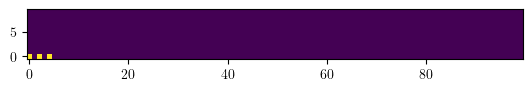

In [48]:
plt.imshow(nangrid, origin='lower')

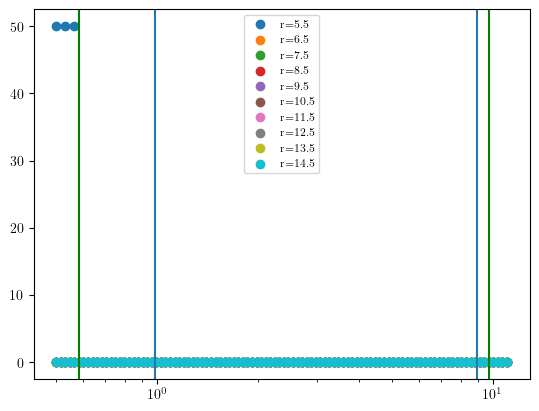

In [7]:
for i in range(len(r_cens[:10])):
    plt.scatter(Mvals, nangrid[i, :], label=f'r={r_cens[i]}')
plt.xscale('log')
plt.axvline(Mvirs[0]/1e14)
plt.axvline(Mvirs[-1]/1e14)
plt.axvline(Mvals[5], c='g')
plt.axvline(Mvals[95], c='g')

plt.legend(fontsize=8)

In [8]:
from scipy.interpolate import interp1d, RegularGridInterpolator, UnivariateSpline

# Create the interpolator
interpolator = RegularGridInterpolator(
    (vcens, r_cens, Mvals[5:]), #Mvals[30:88]
    P_vlos_grid[:, :, 5:],
    method='cubic',  # or 'linear', 'quintic'
    bounds_error=False,
    fill_value=None  # or 0, np.nan
)

In [9]:
# define llh 

def var_diff(R, sp, a, s0):
    Rp = 15 #h^-1 Mpc, pivot scale
    return sp*(R/Rp)**(-a)+s0 

def P_vphys_R_int(M):
    v_mesh, R_mesh = np.meshgrid(vcens, r_cens, indexing='ij')
    points = np.stack([v_mesh.ravel(), R_mesh.ravel(), 
                    np.full(v_mesh.size, M)], axis=1)

    # Evaluate mdoel
    vals = interpolator(points).reshape(len(vcens), len(r_cens))

    return vals 

def RG_llh(pars, data):
    M, sp, a, s0 = pars 

    valid_ind = 0

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    model = P_vphys_R_int(M) 
    norm_model =  model / np.sum(model*dv, axis=0)

    N_avg = np.sum(data, axis=0) * norm_model * dv 

    sigmasq = (data) + var_diff(r_cens, sp, a, s0) * N_avg**2 

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq)) 

def RG_llh_ind(pars, data, r_ind):
    M, s = pars 

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    dist = P_vphys_R_int(M)[:, r_ind]
    dist = dist / np.sum(dist*dv)

    N_avg = np.sum(data) * dist * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq))


def G_llh_ind(pars, data, r_ind):
    M = pars 

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    dist = P_vphys_R_int(M)[:, r_ind]
    dist = dist / np.sum(dist*dv)
    N_avg = np.sum(data) * dist * dv

    sigmasq = N_avg #+ s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 #/ sigmasq  

    #mask = (abs(vcens) > 500)&(abs(vcens) < 1500)

    return - 0.5 * np.sum((chisq)) #+ np.log(sigmasq)


def RG_llh_ind_fixed(pars, data, r_ind, M_ind):
    s = pars 

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1) 

    dist = P_vphys_R_int(Mvirs[M_ind]/1e14)[:, r_ind]
    dist = dist / np.sum(dist*dv)
    N_avg = np.sum(data) * dist * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq)) 


def RG_llh_sim(pars, data):
    M1, M2, M3, M4, M5, M6, sA, smm, smb, ssm, ssb = pars 

    Ms = np.array([M1, M2, M3, M4, M5, M6])

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    norm_model = np.zeros(data.shape)

    for k, M in enumerate(Ms):
        model = P_vphys_R_int(M) 
        norm_model[:, k, :] =  model / np.sum(model*dv, axis=0)

    N_avg = np.sum(data, axis=0) * norm_model * dv 

    sm = plaw(Ms, smm, smb)

    ss = plaw(Ms, ssm, ssb)

    sigmasq = N_avg + erf(r_cens[:, np.newaxis]/15, sA, sm, ss).T**2 * N_avg**2 

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq)) 

#lh_test = RG_llh([Mvirs[0]/1e14, 1, 1, 1], BGS_hists[:, 0, :])
#lh_test 

mvirs = Mvirs/1e14


In [ ]:
# MLE, all mass and individual radial bins
par_mass_ind = np.zeros((len(LOS_hists), len(mvirs), len(r_cens), 2))
err_mass_ind = np.zeros((len(LOS_hists), len(mvirs), len(r_cens)))

for j in range(len(LOS_hists)):
    for k in range(len(mvirs)):
        p_init = [mvirs[k], 0.01] #[Mvirs[0]/1e14, 0.1]

        for i in range(len(r_cens)):
            soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, BGS_hists[j][:, k, i], i), p_init, 
                                        bounds = [(0.5, 20.0), (0, 10)], #(0, np.inf), (0, np.inf), (0, np.inf)], 
                                        method='nelder-mead', 
                                        )
            
            print("Initial: ", p_init) 
            print("MLE: ", soln.x) 
            print(soln.message)

            par_mass_ind[j, k, i] = soln.x 

Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.04496847 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.09573431e+00 1.74067914e-06]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.15085548e+00 1.44958496e-07]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.18908783 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.16025642 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.11242107 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.14189635 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.12439616 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.14239143 0.        ]
Optimization terminated successfully.
Ini

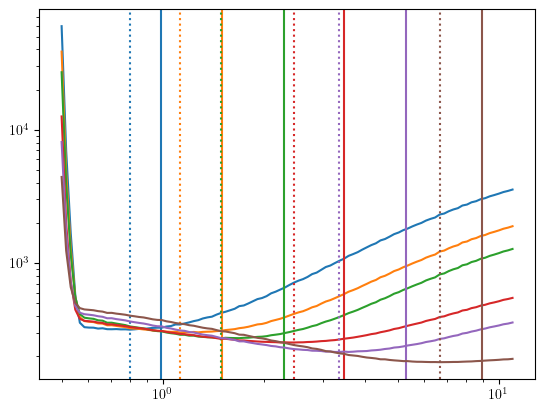

In [41]:
# test: LLH as fcn of mass for some test bin

i = 5
#k = 1
j = 1

for k in range(len(Mvirs)):
    llhs = np.array([-RG_llh_ind([Mvals[m], par_mass_ind[j, k, i, 1]], data=LOS_hists_bin[:, k, i], r_ind = i) for m in range(len(Mvals))])

    plt.plot(Mvals, llhs)
    plt.axvline(mvirs[k], c=f'C{k}')
    #plt.axvline(par_mass_ind[j, k, i, 0], ls='--', c=f'C{k}')
    plt.axvline(Mvals[np.argmin(llhs[~np.isnan(llhs)])], ls=':', c=f'C{k}')

plt.xscale('log')
plt.yscale('log')

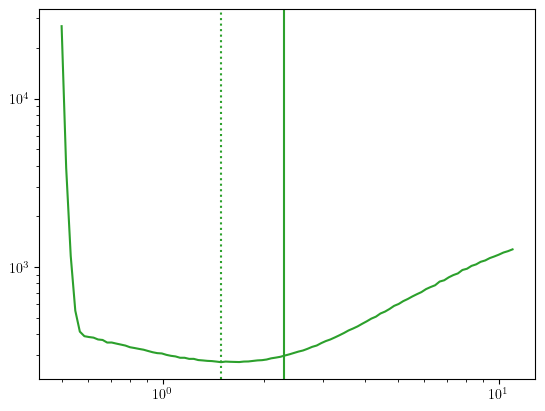

In [44]:
k = 2
llhs = np.array([-RG_llh_ind([Mvals[m], par_mass_ind[j, k, i, 1]], data=LOS_hists_bin[:, k, i], r_ind = i) for m in range(len(Mvals))])

plt.plot(Mvals, llhs, c=f'C{k}')
plt.axvline(mvirs[k], c=f'C{k}')
#plt.axvline(par_mass_ind[j, k, i, 0], ls='--', c=f'C{k}')
plt.axvline(Mvals[np.argmin(llhs[~np.isnan(llhs)])], ls=':', c=f'C{k}')

plt.xscale('log')
plt.yscale('log')

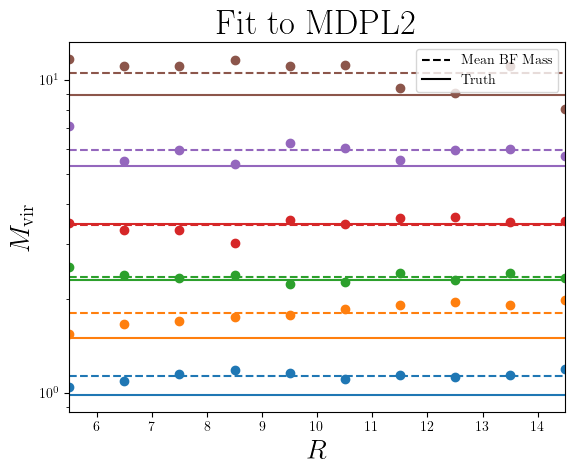

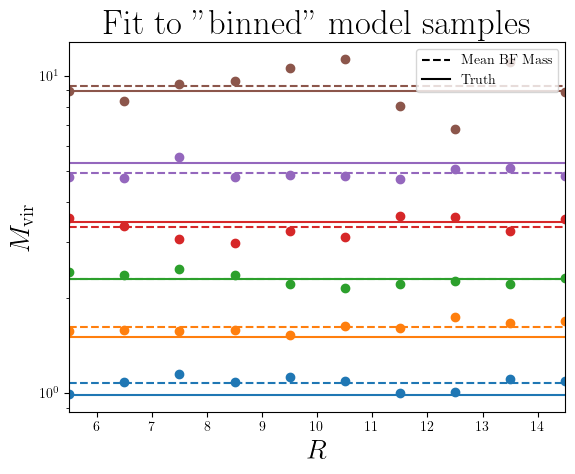

In [37]:
from matplotlib.lines import Line2D

titles = ['Fit to MDPL2', 'Fit to "binned" model samples', 'Fit to "individual" model samples']

for j in range(len(LOS_hists)):
    fig, ax = plt.subplots()

    for k in range(len(mvirs)):#
        ax.scatter(r_cens, par_mass_ind[j, k, :, 0], c=f'C{str(k)}')
        ax.axhline(np.mean(par_mass_ind[j, k, :, 0]), ls='--', c=f'C{str(k)}')
        ax.axhline(mvirs[k], ls='-', c=f'C{str(k)}', )


    marker_1 = Line2D(
        [0], [0],
        color='k',          
        marker='none',
        linestyle='--',
        label='Mean BF Mass', 

    )

    marker_2 = Line2D(
        [0], [0],
        color='k',          
        marker='none',
        linestyle='-',
        label='Truth'
    )

    ax.set_xlabel(r'$R$', fontsize=20)
    ax.set_ylabel(r'$M_{\rm vir}$', fontsize=20)
    ax.set_yscale('log')
    ax.margins(x=0)
    ax.set_title(titles[j], fontsize=25)
    plt.legend(handles=[marker_1, marker_2], fontsize=10)


In [ ]:
(np.float64(-0.0027378047119542706), np.float64(0.05749389895103968))

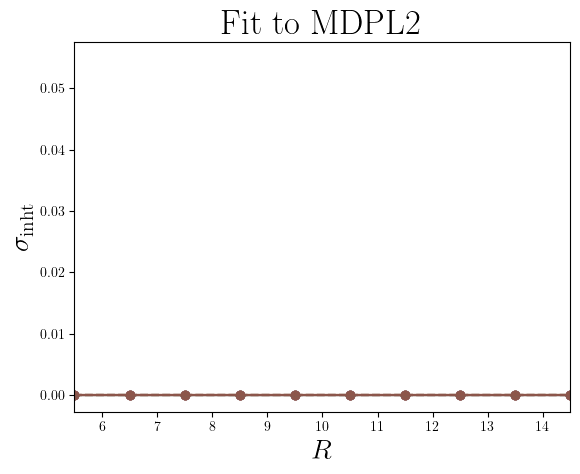

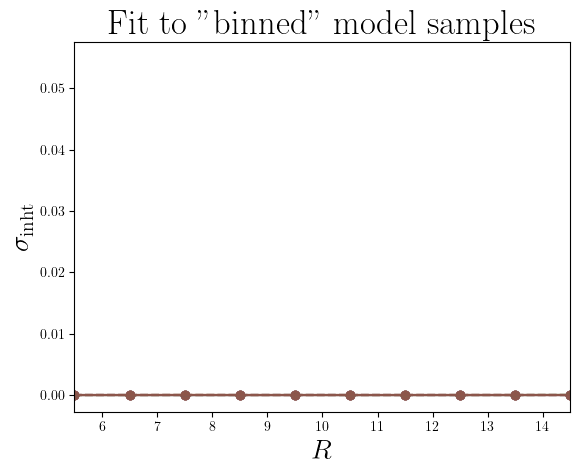

In [50]:

for j in range(len(LOS_hists)):
    fig, ax = plt.subplots()

    for k in range(len(mvirs)):#

        ax.scatter(r_cens, par_mass_ind[j, k, :, 1], c=f'C{str(k)}')
        ax.plot(r_cens, par_mass_ind[j, k, :, 1], c=f'C{str(k)}')
        ax.axhline(np.mean(par_mass_ind[j, k, :, 1]), ls='--', c=f'C{str(k)}')

        #ax.axhline(np.mean(par_mass_ind[j, k, :, 1]), ls='--', c=f'C{str(k)}')
        #ax.axhline(mvirs[k], ls='-', c=f'C{str(k)}', )
        
    ax.set_xlabel(r'$R$', fontsize=20)
    ax.set_ylabel(r'$\sigma_{\rm inht}$', fontsize=20)
    #ax.set_yscale('log')
    ax.set_ylim(np.float64(-0.0027378047119542706), np.float64(0.05749389895103968))
    ax.set_title(titles[j], fontsize=25)
    ax.margins(x=0)
    #print(ax.get_ylim())

In [14]:
def closest_argmin(A, B):
    L = B.size
    sidx_B = B.argsort()
    sorted_B = B[sidx_B]
    sorted_idx = np.searchsorted(sorted_B, A)
    sorted_idx[sorted_idx==L] = L-1
    mask = (sorted_idx > 0) & \
    ((np.abs(A - sorted_B[sorted_idx-1]) < np.abs(A - sorted_B[sorted_idx])) )
    return sidx_B[sorted_idx-mask]

inds = closest_argmin(mvirs, Mvals)

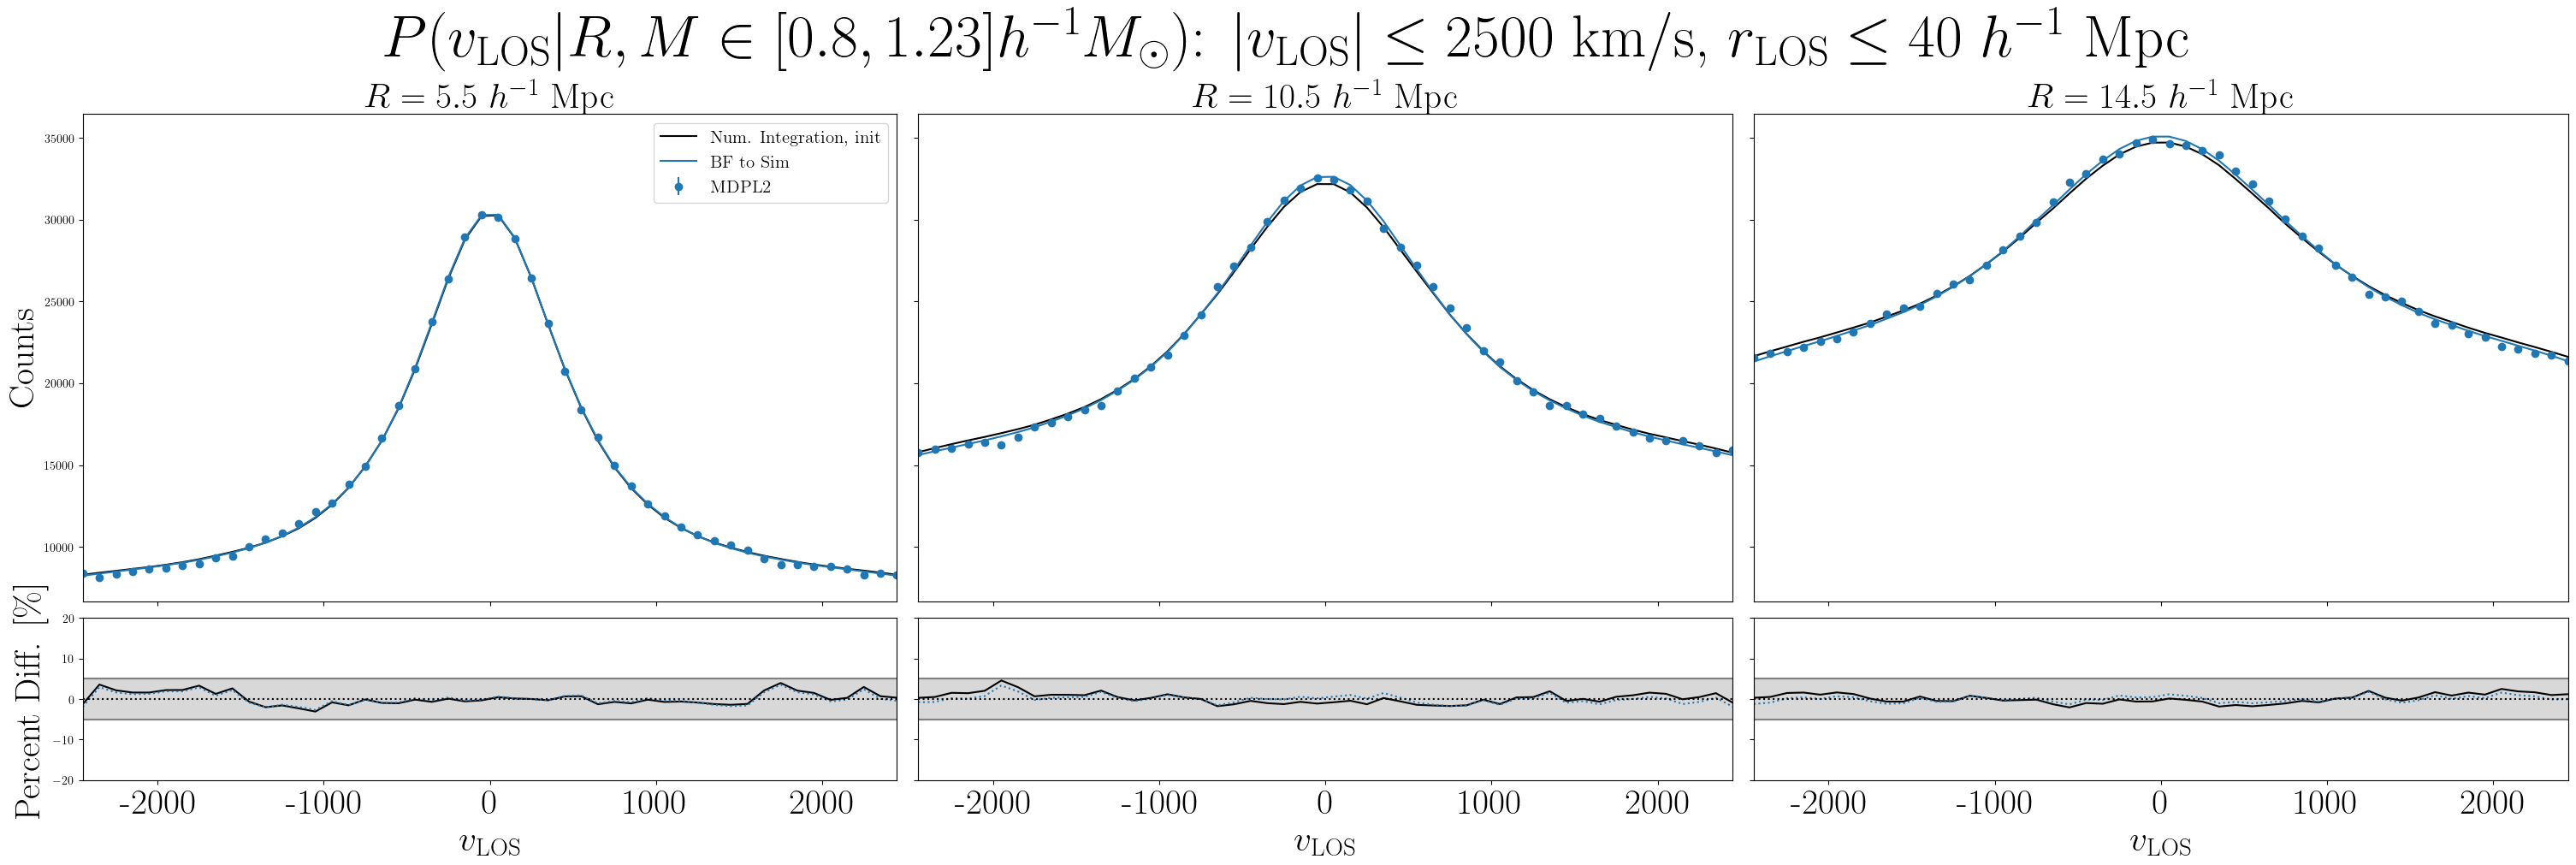

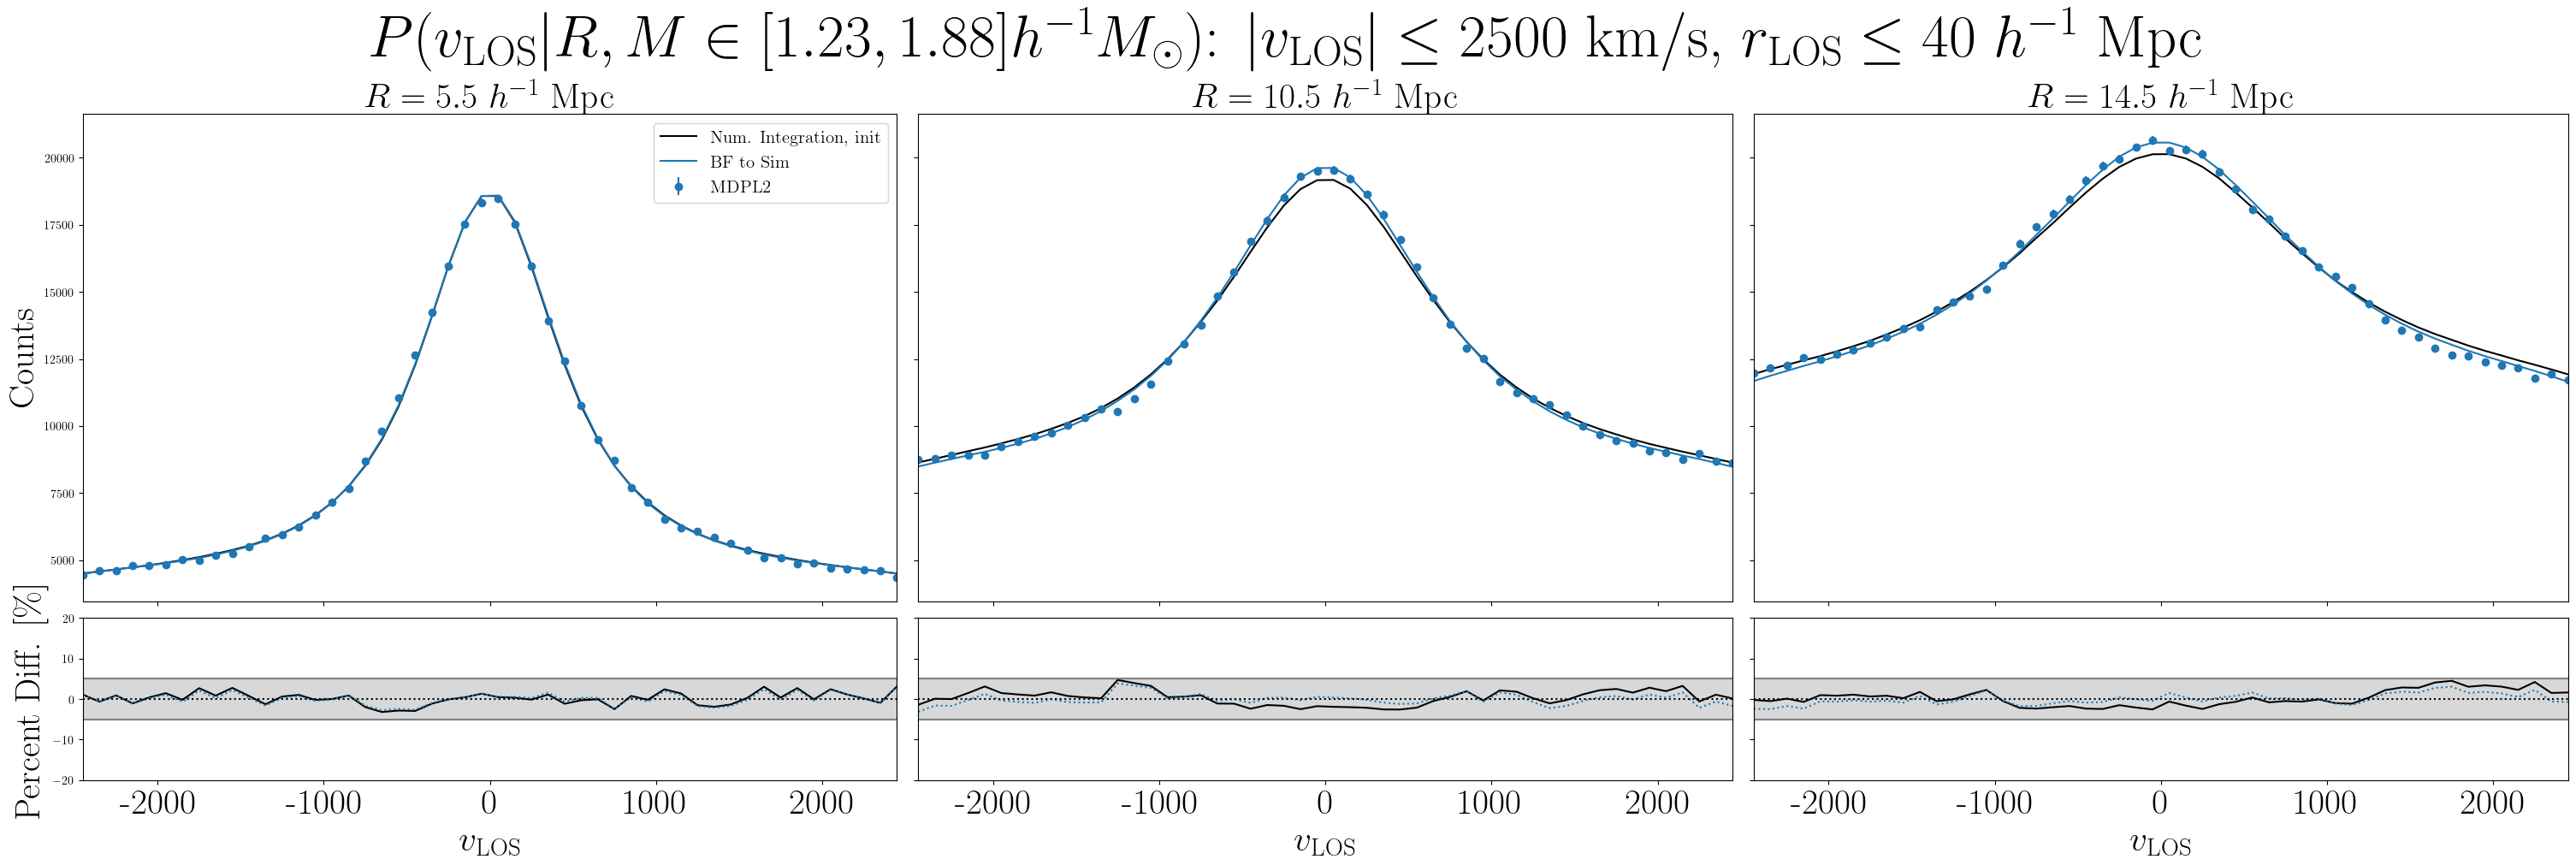

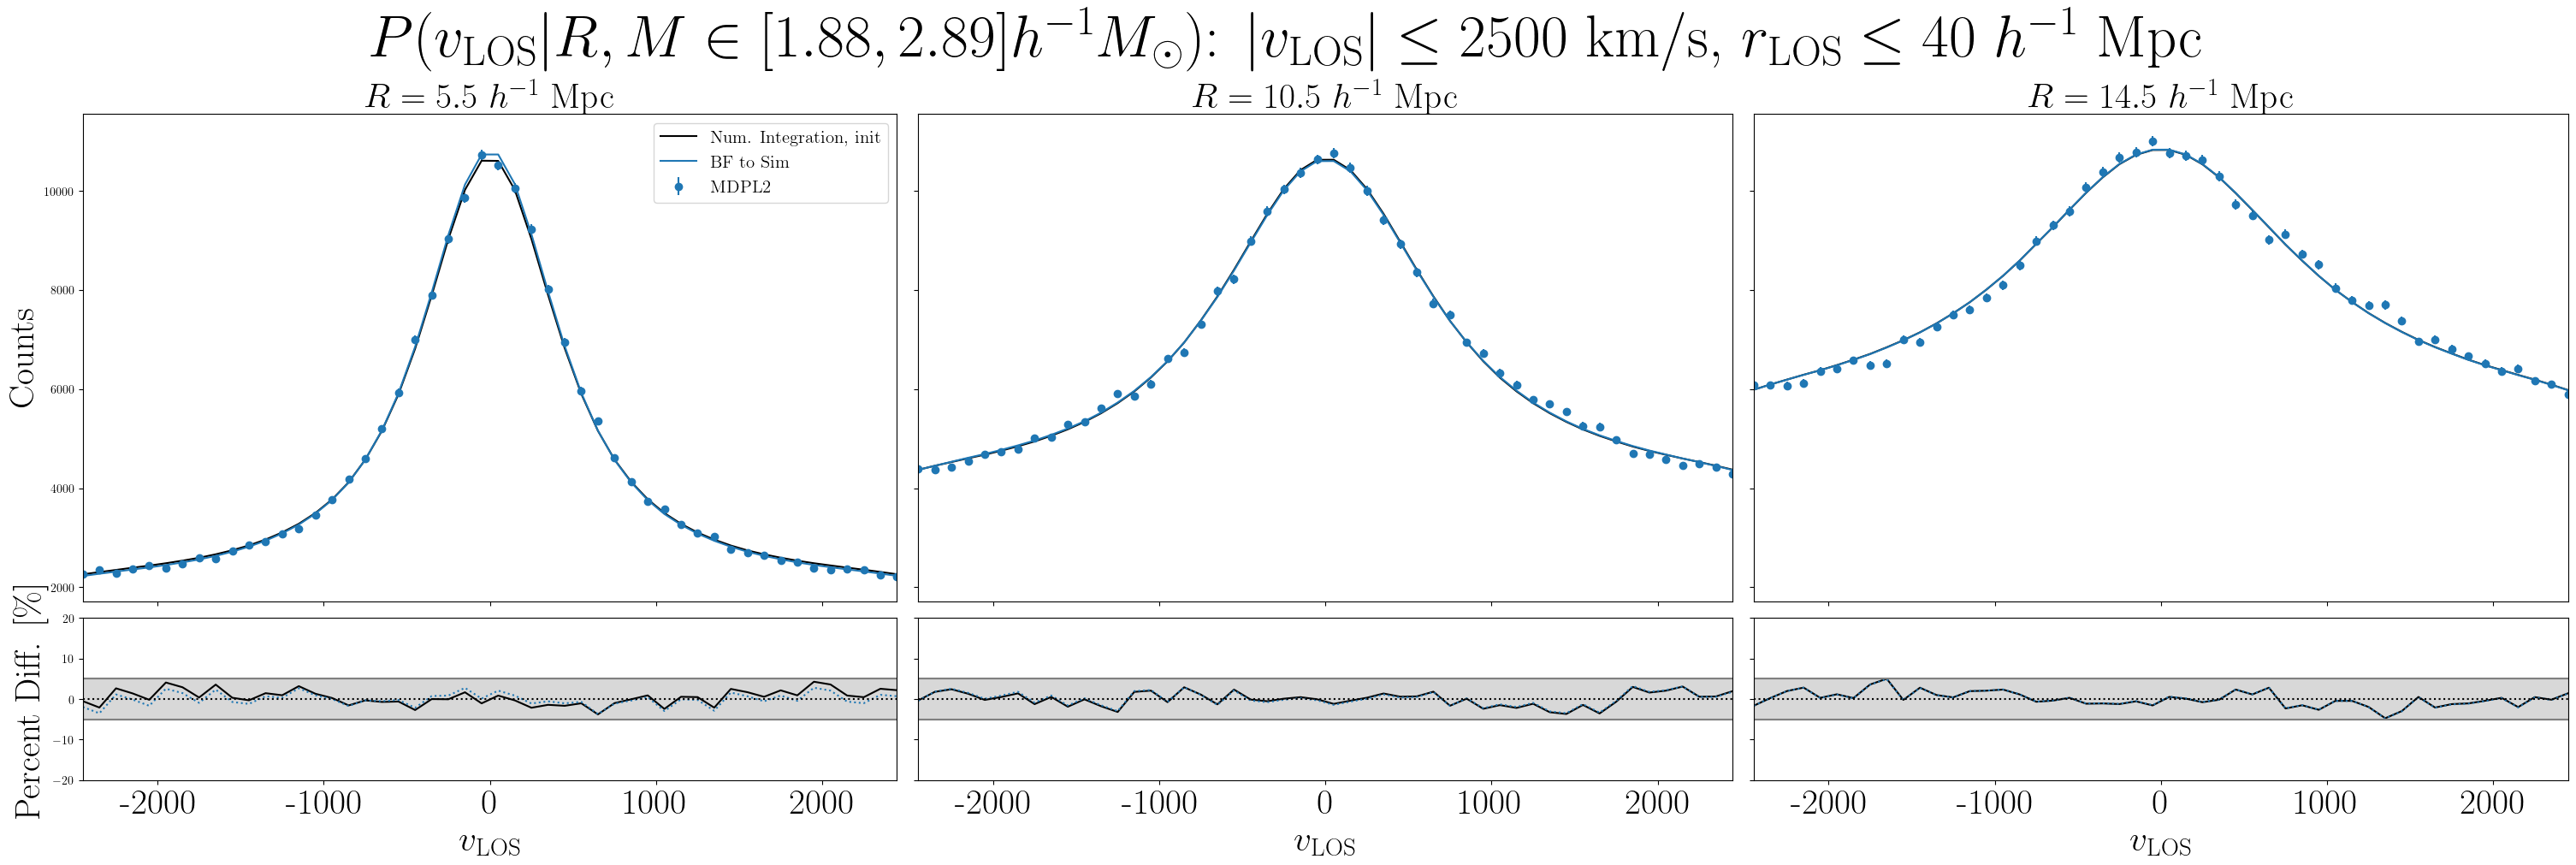

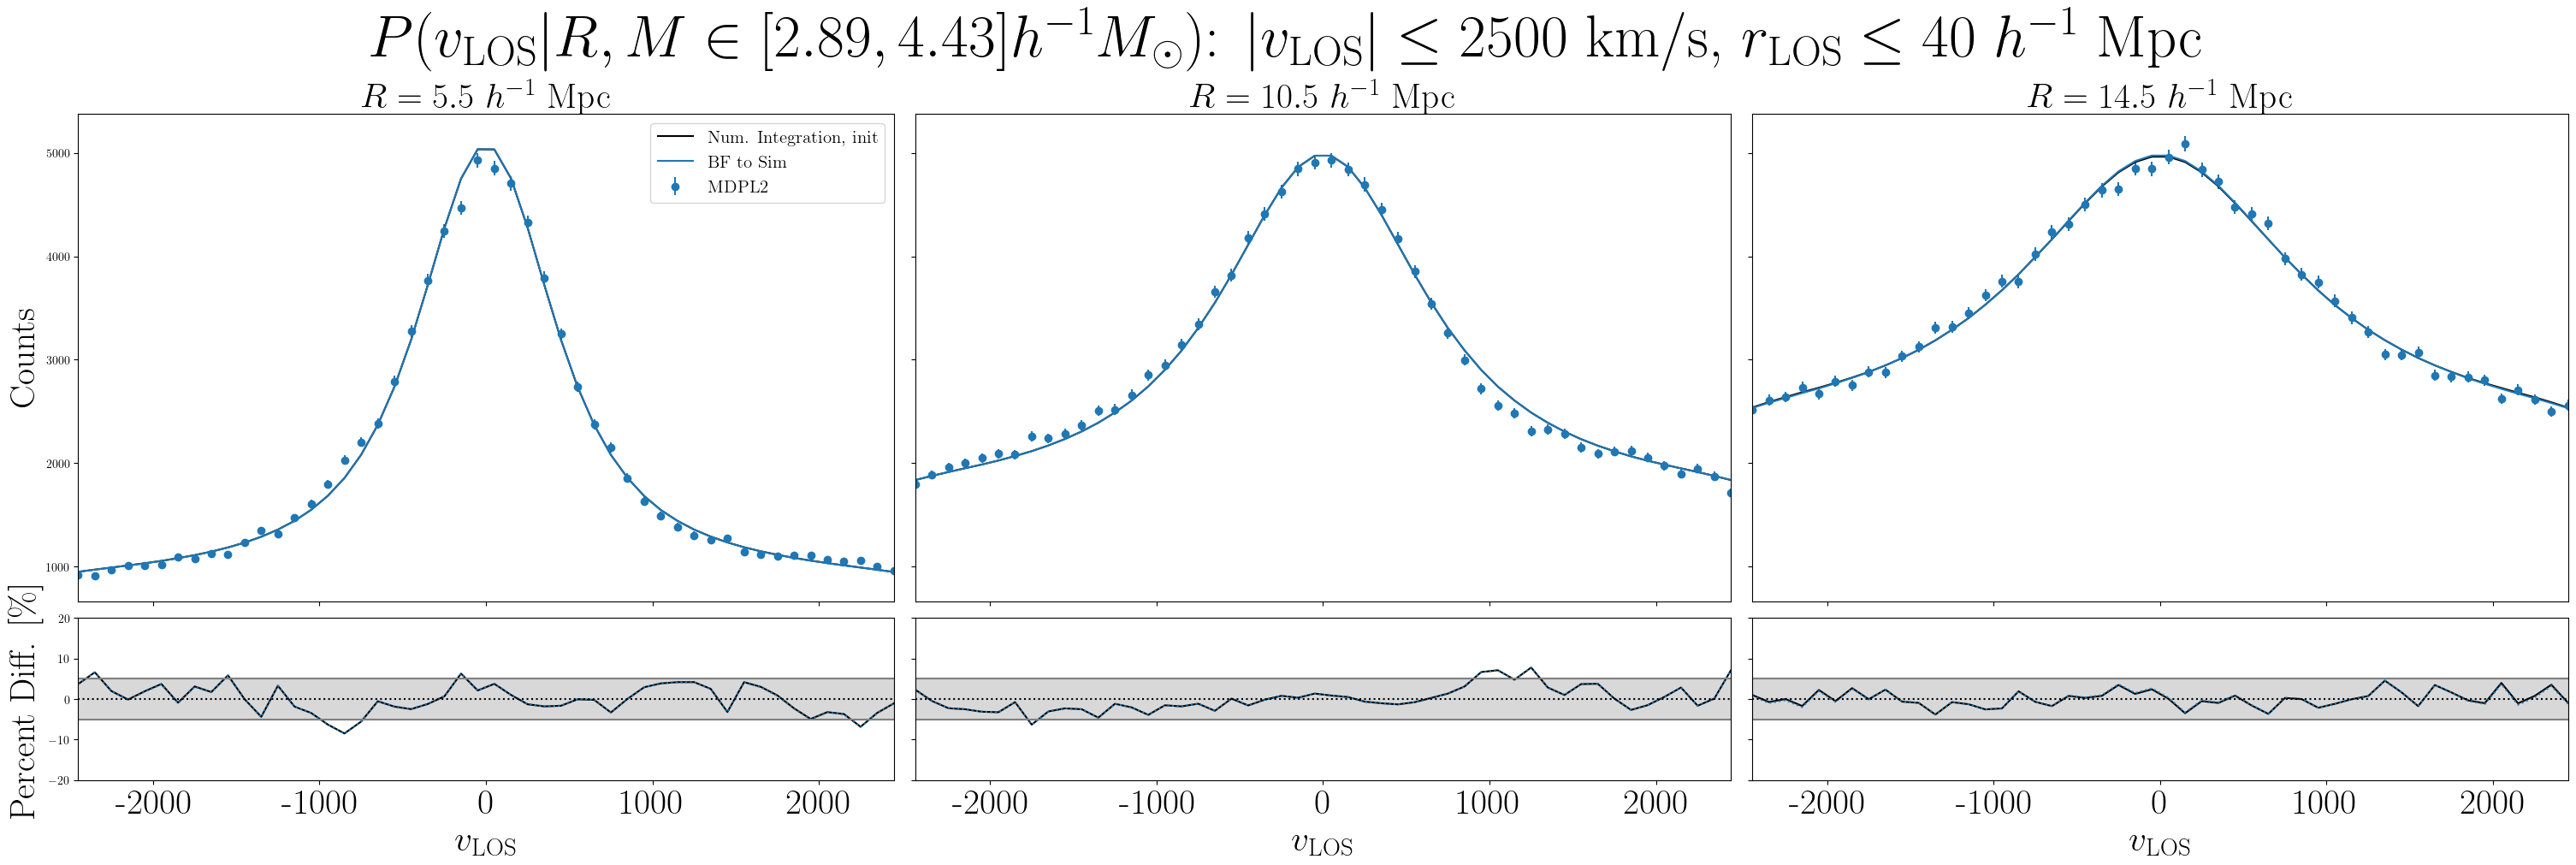

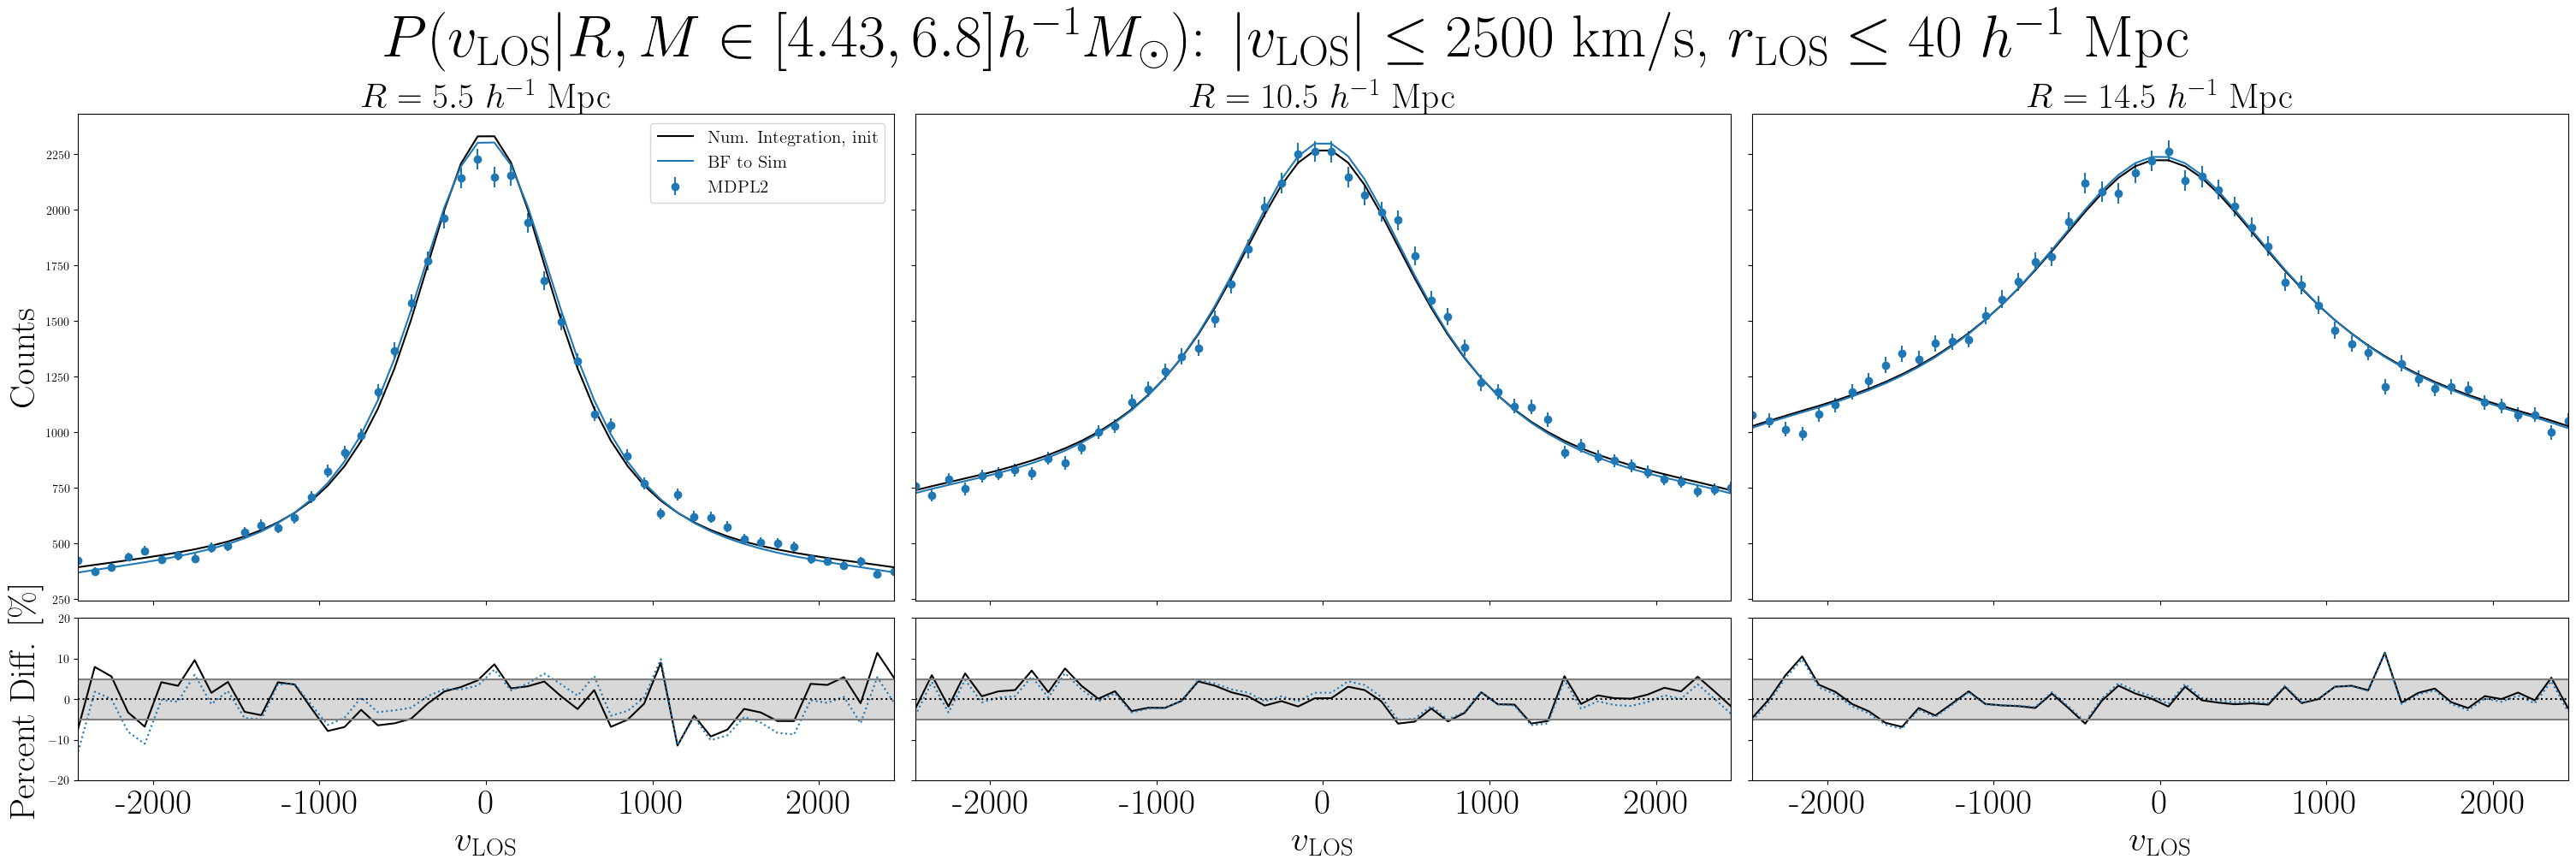

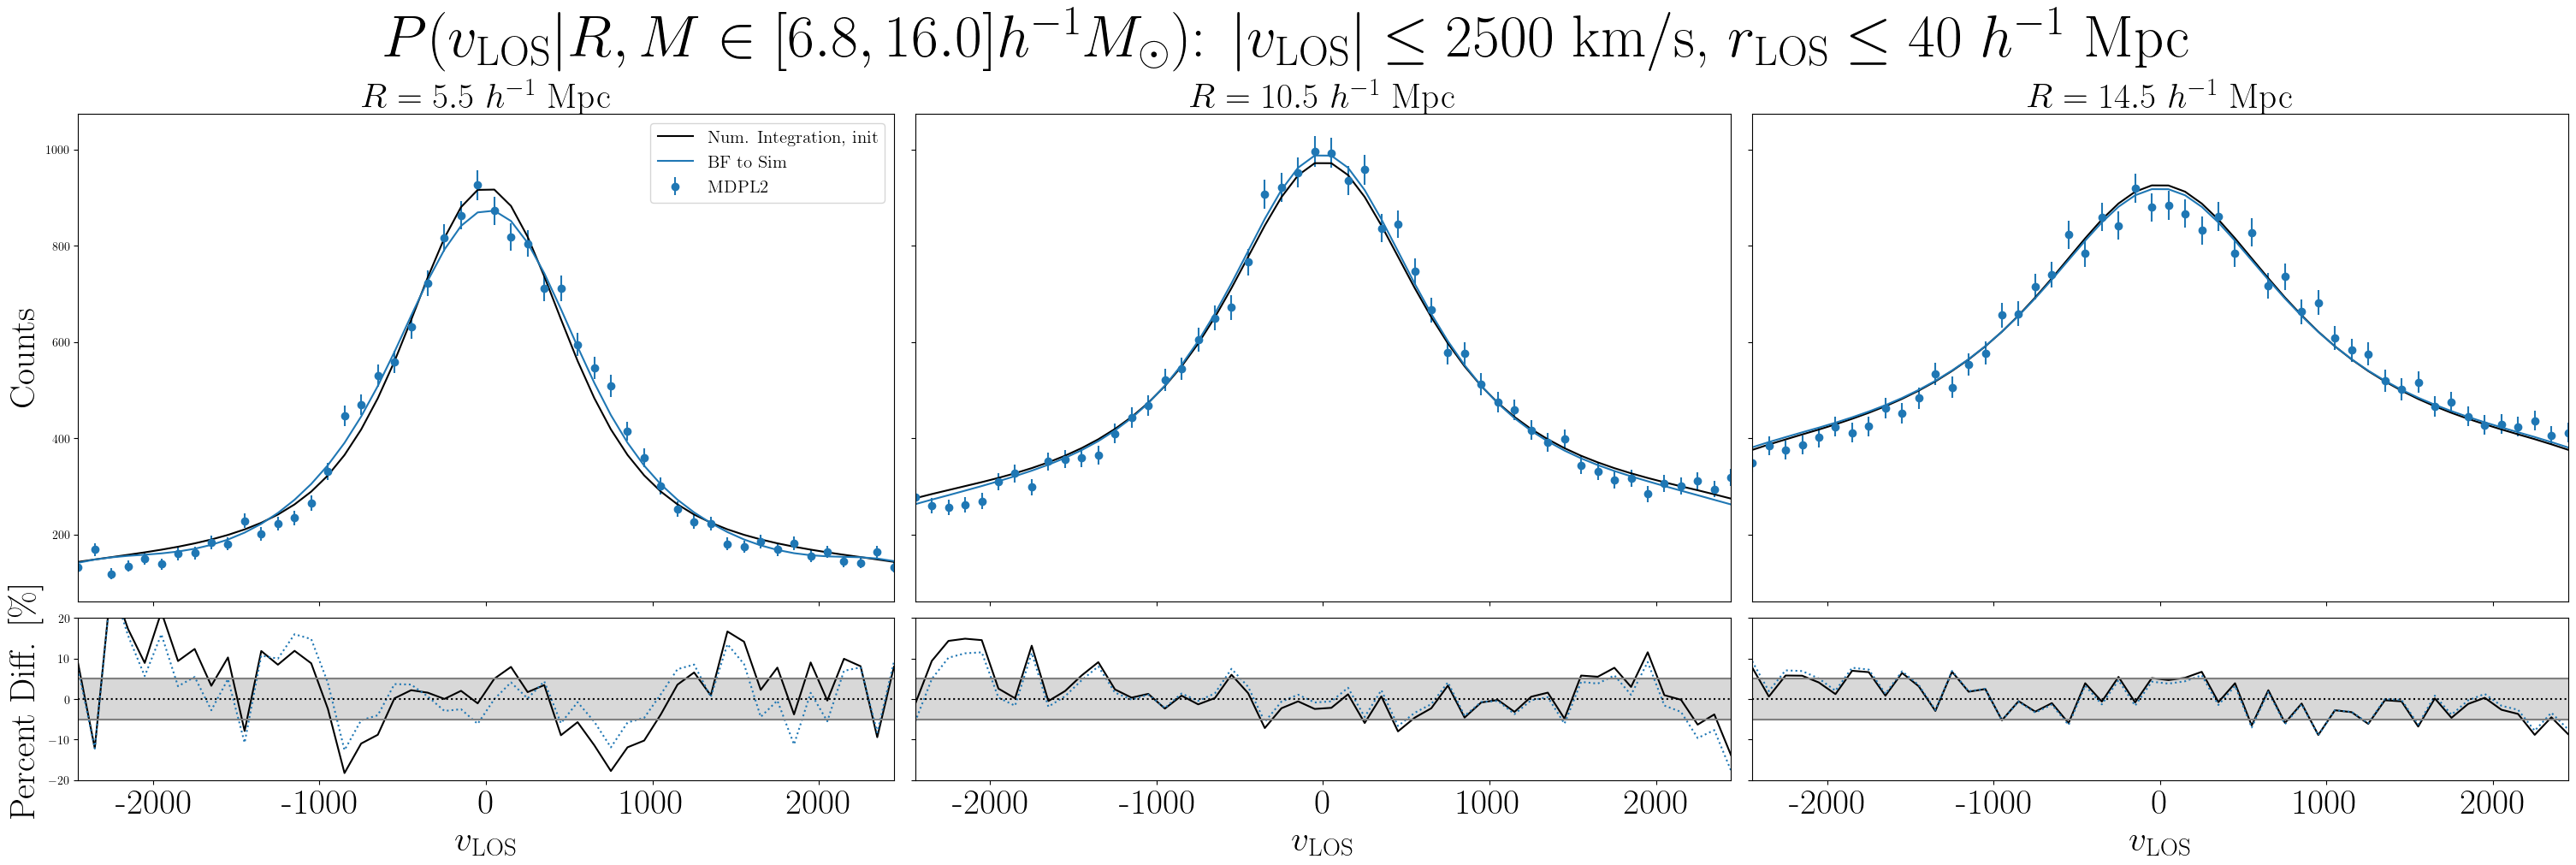

In [51]:
# validate

# check quality of "fit" over mass bins with vlos < 2K km/s 

# compare histograms  
mvirs = Mvirs/1e14
bin_num = 50 #120

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

#for j in range(1):
for k in range(len(mvirs)):
    #k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, sharey='row', layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist, bins_ex = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        hist_bin, bins_ex = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        #hist_ind, bins_ex = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist =  P_vphys_R_int(Mvals[inds[k]])[:, r_select_inds[i]]
        dist_out = P_vphys_R_int(par_mass_ind[0, k, r_select_inds[i], 0])[:, r_select_inds[i]]
        #dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

        # dist2 = P_vphys_R_int(par_mass_ind[1, k, i, 0])[:, r_select_inds[i]]
        # dist2 = dist2 / np.sum(dist2*np.diff(vcens_ex)[0])

        # dist3 =  P_vphys_R_int(par_mass_ind[2, k, i, 0])[:, r_select_inds[i]]
        # dist3 = dist3 / np.sum(dist3*np.diff(vcens_ex)[0])

        N_avg = np.sum(hist)*dist*np.diff(vcens_ex)[0]
        N_avg2 = np.sum(hist_bin)*dist_out*np.diff(vcens_ex)[0]
        N_avg3 = np.sum(hist)*dist_out*np.diff(vcens_ex)[0]

        ax[0, i].errorbar(vcens_ex, hist, np.sqrt(hist), fmt='o', c=f'C0', label='MDPL2') #
        #ax[0, i].errorbar(vcens_ex, hist_bin, np.sqrt(hist_bin), fmt='o', marker='s', c=f'C1', label='Model Samples') #
        #ax[0, i].errorbar(vcens_ex, hist_ind, np.sqrt(hist_ind), fmt='o', marker='x', c=f'C{str(k)}') #

        ax[0, i].plot(vcens_ex, N_avg, c='k', label='Num. Integration, init')# 
        #ax[0, i].plot(vcens_ex, N_avg2, c='C1', label='BF to MS')# 
        ax[0, i].plot(vcens_ex, N_avg3, c='C0', label='BF to Sim')# 

        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens_ex, (N_avg - hist)/hist * 100, c='k')
        #ax[1, i].plot(vcens_ex, (N_avg2 - hist_bin)/hist_bin * 100, c='C1')
        ax[1, i].plot(vcens_ex, (N_avg3 - hist)/hist * 100, ls=':', c='C0')

        #print(np.sum((N_avg - hist)**2/hist ), np.sum((N_avg3 - hist)**2/hist ))
        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='-')
        ax[1, i].fill_between(vcens_ex, 5, -5, color='gray', alpha=0.3)
        ax[1, i].axhline(-5, c='gray', ls='-')
        ax[1, i].set_ylim((-20, 20))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xticklabels(['-2000', '-1000', '0', '1000', '2000'], fontsize=30)
    ax[0, 0].legend(loc='upper right', fontsize=15)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"$P(v_{{\rm LOS}}|R, M\in[{}, {}] h^{{-1}}M_\odot)$: $|v_{{\rm LOS}}| \leq {}$ km/s, $r_{{\rm LOS}} \leq 40 \ h^{{-1}}$ Mpc".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), 2500), fontsize=50)  

In [15]:
def RG_llh_sim(pars, data):
    M1, M2, M3, M4, M5, M6, s = pars 

    Ms = np.array([M1, M2, M3, M4, M5, M6])

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    norm_model = np.zeros(data.shape)

    for k, M in enumerate(Ms):
        model = P_vphys_R_int(M) 
        norm_model[:, k, :] =  model / np.sum(model*dv, axis=0)

    N_avg = np.sum(data, axis=0) * norm_model * dv 

    sigmasq = N_avg + s**2 * N_avg**2 

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq)) 

In [52]:
# MLE over masses simultaneously
par_mass_sim = np.zeros((len(LOS_hists), 7))
err_mass_sim = np.zeros((len(LOS_hists), 7))
p_init = np.append(mvirs, 0.02)

Bounds = [(mbins[i]/1e14, mbins[i+1]/1e14) for i in range(len(mvirs))]

for i in range(len(LOS_hists)):
    soln = scipy.optimize.minimize(lambda p: -RG_llh_sim(p, BGS_hists[i]), p_init, 
                                #bounds = Bounds, #[(0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0)], #[(0.5, 20.0), (0, np.inf), (0, np.inf), (0, np.inf)], 
                                method='nelder-mead', 
                                options={'maxiter':10_000}
                                )

    print("Initial: ",p_init) 
    print("MLE: ", soln.x) 
    print(soln.message)

    par_mass_sim[i] = soln.x 

Initial:  [0.98642004 1.49829996 2.29630017 3.46530008 5.30749989 8.93109989
 0.02      ]
MLE:  [1.11940595e+00 1.75139463e+00 2.36084459e+00 3.48014733e+00
 5.84543693e+00 1.12482881e+01 9.91865641e-08]
Optimization terminated successfully.
Initial:  [0.98642004 1.49829996 2.29630017 3.46530008 5.30749989 8.93109989
 0.02      ]
MLE:  [ 1.08040256e+00  1.59037867e+00  2.30507783e+00  3.21092076e+00
  4.91566665e+00  9.01973049e+00 -4.28576569e-08]
Optimization terminated successfully.


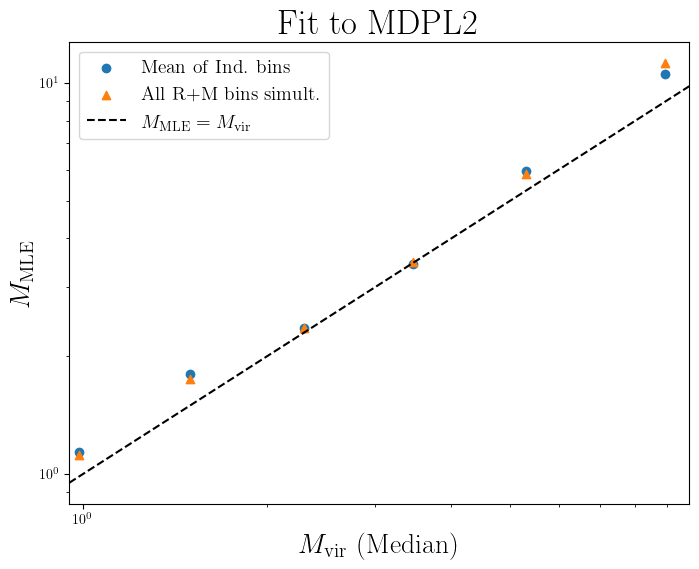

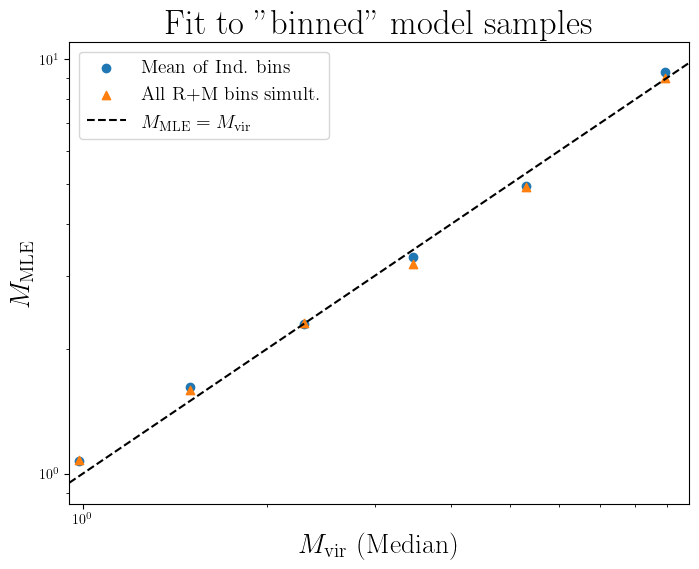

In [53]:
ms = np.linspace(0.95, 9.8, 100)

def plawc(x, p, s, c):
    return p*(x)**s+c

M_est_pars = np.zeros((len(LOS_hists), 3))

for i in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))
    p, c = curve_fit(plawc, mvirs, par_mass_sim[i][:-1])
    M_est_pars[i] = p
    ax.scatter(mvirs, np.mean(par_mass_ind[i, :, :, 0], axis=-1), label='Mean of Ind. bins')
    #ax.scatter(mvirs, par_mass[:, 0], marker='s', label=r'All R $|$ M')
    ax.scatter(mvirs, par_mass_sim[i][:-1], marker='^', label='All R+M bins simult.')
    ax.plot(ms, line(ms, 1, 0), c='k', ls='--', label=r'$M_{\rm MLE} = M_{\rm vir}$')
    #ax.plot(ms, plawc(ms, p[0], p[1], p[2]), c='C3', ls='-', label=r'$a M_{\rm vir}^b+c$')
    ax.margins(x=0)
    ax.set_ylabel(r'$M_{\rm MLE}$', fontsize=20)
    ax.set_xlabel(r'$M_{\rm vir}$ (Median)', fontsize=20)
    ax.legend(fontsize=14)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim((0.95, 9.8))
    ax.set_title(titles[i], fontsize=25)


In [62]:
# remake plots with *mean* Mvir

with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as pc:
    print(pc.keys(), end=' ')

    tag = np.array(pc['tag'])
    orbit_mask = (tag == 0)
    infall_mask = (tag == 1) 

    hostmvir = np.array(pc['hostmvir'])
    hostrvir = np.array(pc['hostrvir'])

    #Massbins
    print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
    print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')

    #mini=hostmvir.min()
    #maxi=1.6e15#pc['hostmvir'].max()

    #Choose Bins: Log-spaced bins between min and max
    #massbins = np.logspace( np.log10(mini), np.log10(maxi), 7+1)
    #mbins = np.delete(massbins, -2)
    #print('massbins:', mbins)

    Rvirs_mean=[]
    Mvirs_mean=[]
    for i in range(len(mbins)-1):
        mmask = (hostmvir>=mbins[i])&(hostmvir<=mbins[i+1])
        orbi_M = hostmvir[mmask&orbit_mask]
        orbi_R = hostrvir[mmask&orbit_mask]
        print(mbins[i]/1e14, mbins[i+1]/1e14)

        Rvirs_mean.append(np.mean(orbi_R))
        Mvirs_mean.append(np.mean(orbi_M))
    Rvirs_mean=np.array(Rvirs_mean)
    Mvirs_mean=np.array(Mvirs_mean)

<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_156763/4074089807.py:14: SyntaxWarning: invalid escape sequence '\o'
  print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
/tmp/ipykernel_156763/4074089807.py:15: SyntaxWarning: invalid escape sequence '\o'
  print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')


<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
0.8000202269281375 1.2273285213892782
1.2273285213892782 1.882871518385872
1.882871518385872 2.888554362556256
2.888554362556256 4.431394401565781
4.431394401565781 6.798299037325463
6.798299037325463 16.000000000000007


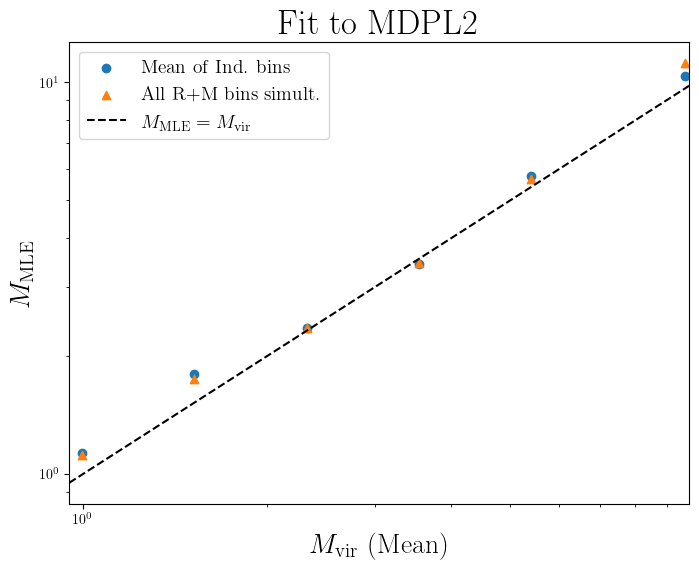

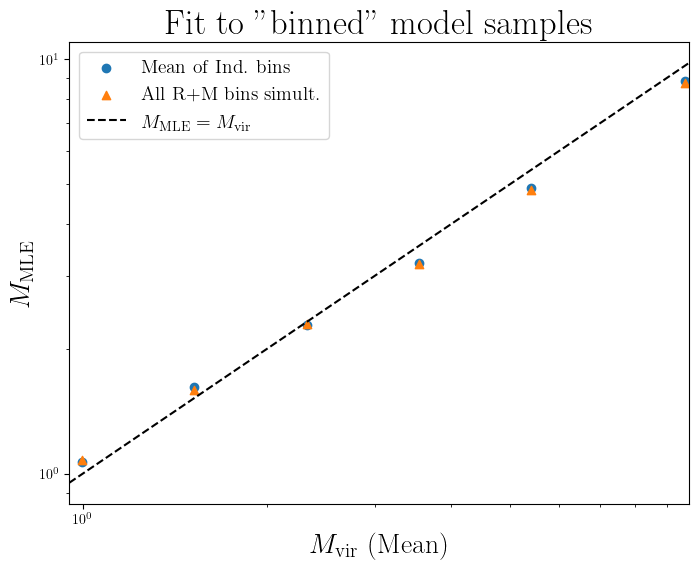

In [63]:
mmeans = Mvirs_mean/1e14


def plawc(x, p, s, c):
    return p*(x)**s+c

for i in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))
    #p, c = curve_fit(plawc, mmeans, par_mass[:, 0])
    ax.scatter(mmeans, np.mean(par_mass_ind[i, :, :, 0], axis=-1), label='Mean of Ind. bins')
    #ax.scatter(mmeans, par_mass[:, 0], marker='s', label=r'All R $|$ M')
    ax.scatter(mmeans, par_mass_sim[i], marker='^', label='All R+M bins simult.')
    ax.plot(ms, line(ms, 1, 0), c='k', ls='--', label=r'$M_{\rm MLE} = M_{\rm vir}$')
    #ax.plot(ms, plawc(ms, p[0], p[1], p[2]), c='C3', ls='-', label=r'$a M_{\rm vir}^b+c$')
    ax.margins(x=0)
    ax.set_ylabel(r'$M_{\rm MLE}$', fontsize=20)
    ax.set_xlabel(r'$M_{\rm vir}$ (Mean)', fontsize=20)
    ax.legend(fontsize=14)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim((0.95, 9.8))
    ax.set_title(titles[i], fontsize=25)


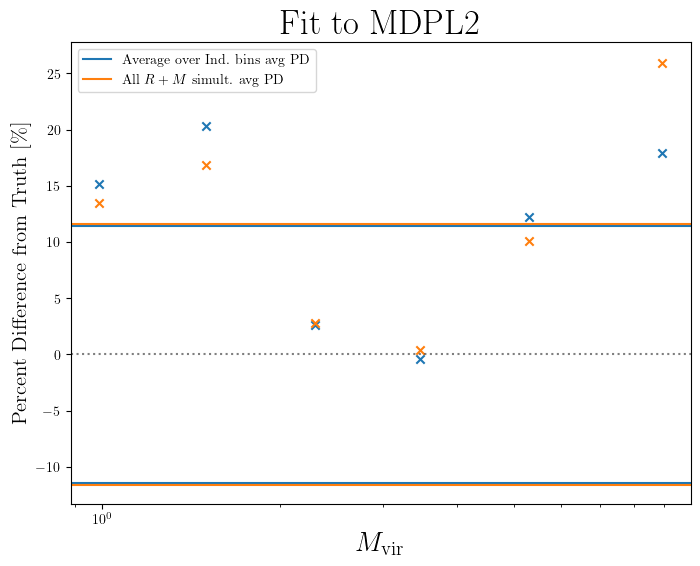

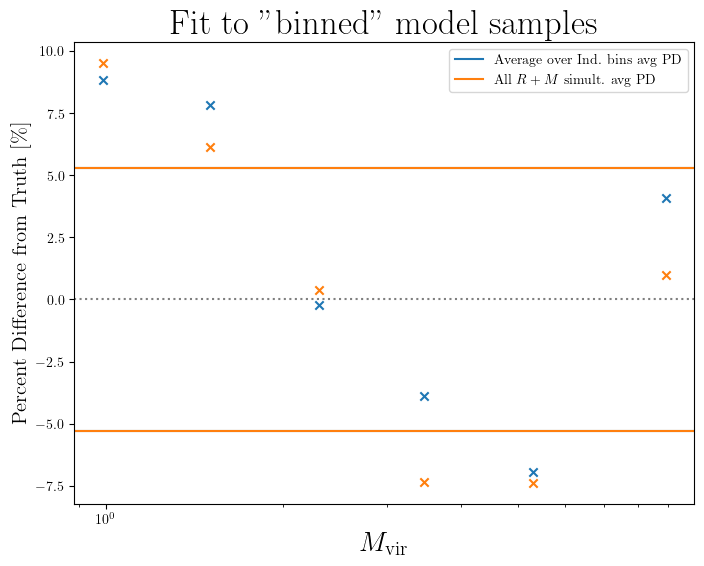

In [54]:
for j in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))

    ax.scatter(mvirs, ((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs)*100, marker='x')
    ax.axhline(np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs))*100, label=r'Average over Ind. bins avg PD') 
    ax.axhline(-np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs))*100 ) 


    #ax.scatter(mvirs, ((par_mass_ind[j, :, 0]-mvirs)/mvirs)*100, marker='x')
    #ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-mvirs)/mvirs))*100, label=r'All $R | M$', c='C1') 

    ax.scatter(mvirs, ((par_mass_sim[j][:-1]-mvirs)/mvirs)*100, marker='x')
    ax.axhline(np.mean(np.abs((par_mass_sim[j][:-1]-mvirs)/mvirs))*100, label=r'All $R+M$ simult. avg PD', c='C1') 
    ax.axhline(-np.mean(np.abs((par_mass_sim[j][:-1]-mvirs)/mvirs))*100, c='C1') 

    ax.axhline(0.0, c='k', ls=':', alpha=0.5)
    ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
    ax.set_ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
    ax.set_xscale('log')
    #ax.set_ylim((-5, 5))
    ax.set_title(titles[j], fontsize=25)
    ax.legend()

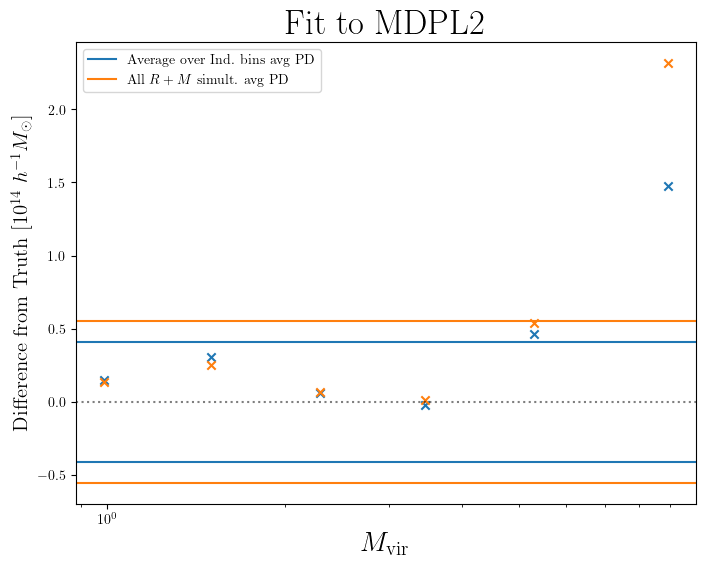

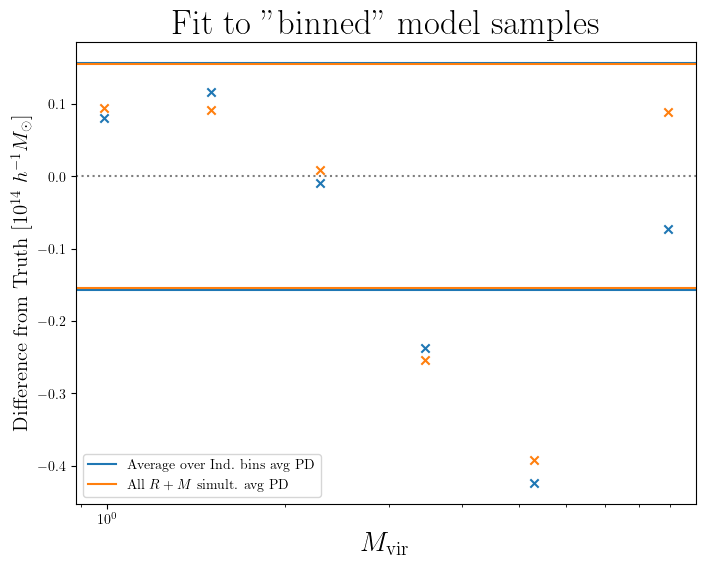

In [22]:
for j in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))

    ax.scatter(mvirs, ((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)), marker='x')
    ax.axhline(np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs))), label=r'Average over Ind. bins avg PD') 
    ax.axhline(-np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs))) ) 


    #ax.scatter(mvirs, ((par_mass_ind[j, :, 0]-mvirs)), marker='x')
    #ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-mvirs))), label=r'All $R | M$', c='C1') 

    ax.scatter(mvirs, ((par_mass_sim[j][:-1]-mvirs)), marker='x')
    ax.axhline(np.mean(np.abs((par_mass_sim[j][:-1]-mvirs))), label=r'All $R+M$ simult. avg PD', c='C1') 
    ax.axhline(-np.mean(np.abs((par_mass_sim[j][:-1]-mvirs))), c='C1') 

    ax.axhline(0.0, c='k', ls=':', alpha=0.5)
    ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
    ax.set_ylabel(r"Difference from Truth $[10^{14} \ h^{-1} M_\odot]$", fontsize=15) 
    ax.set_xscale('log')
    #ax.set_ylim((-5, 5))
    ax.set_title(titles[j], fontsize=25)
    ax.legend()

In [ ]:
for j in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))

    ax.scatter(mvirs, ((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs)*100, marker='x')
    ax.axhline(np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs))*100, label=r'Average over Ind. bins avg PD') 
    ax.axhline(-np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mvirs)/mvirs))*100 ) 


    #ax.scatter(mvirs, ((par_mass_ind[j, :, 0]-mvirs)/mvirs)*100, marker='x')
    #ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-mvirs)/mvirs))*100, label=r'All $R | M$', c='C1') 

    ax.scatter(mvirs, ((par_mass_sim[j][:-1]-mvirs)/mvirs)*100, marker='x')
    ax.axhline(np.mean(np.abs((par_mass_sim[j][:-1]-mvirs)/mvirs))*100, label=r'All $R+M$ simult. avg PD', c='C1') 
    ax.axhline(-np.mean(np.abs((par_mass_sim[j][:-1]-mvirs)/mvirs))*100, c='C1') 

    ax.axhline(0.0, c='k', ls=':', alpha=0.5)
    ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
    ax.set_ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
    ax.set_xscale('log')
    #ax.set_ylim((-5, 5))
    ax.set_title(titles[j], fontsize=25)
    ax.legend()

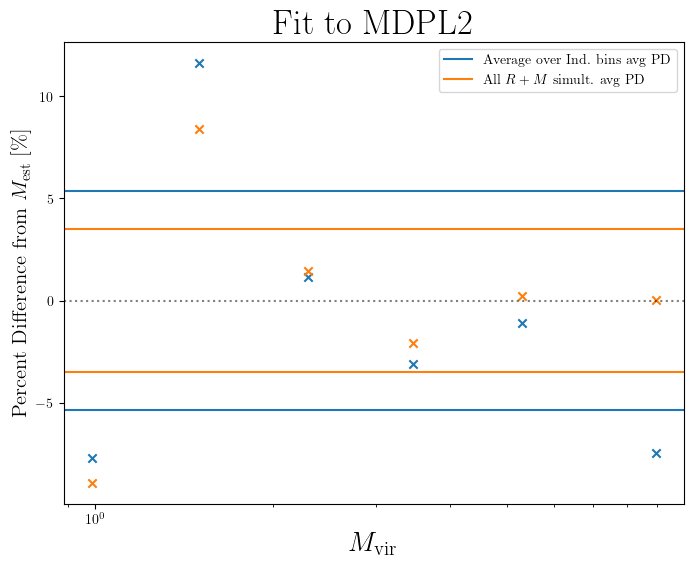

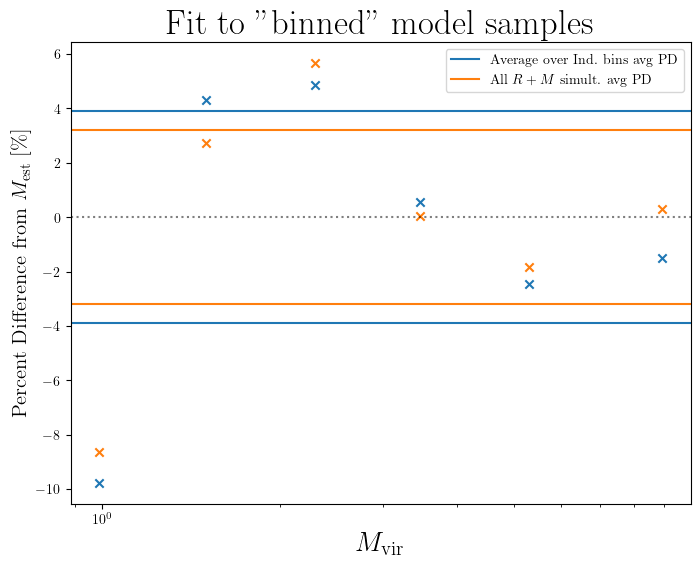

In [21]:
for j in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))

    p = M_est_pars[j]
    M_est = plawc(mvirs, p[0], p[1], p[2])

    ax.scatter(mvirs, ((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-M_est)/M_est)*100, marker='x')
    ax.axhline(np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-M_est)/M_est))*100, label=r'Average over Ind. bins avg PD') 
    ax.axhline(-np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-M_est)/M_est))*100 ) 


    #ax.scatter(mvirs, ((par_mass_ind[j, :, 0]-M_est)/M_est)*100, marker='x')
    #ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-M_est)/M_est))*100, label=r'All $R | M$', c='C1') 

    ax.scatter(mvirs, ((par_mass_sim[j][:-1]-M_est)/M_est)*100, marker='x')
    ax.axhline(np.mean(np.abs((par_mass_sim[j][:-1]-M_est)/M_est))*100, label=r'All $R+M$ simult. avg PD', c='C1') 
    ax.axhline(-np.mean(np.abs((par_mass_sim[j][:-1]-M_est)/M_est))*100, c='C1') 

    ax.axhline(0.0, c='k', ls=':', alpha=0.5)
    ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
    ax.set_ylabel(r"Percent Difference from $M_{\rm est}$ $[\%]$", fontsize=15) 
    ax.set_xscale('log')
    #ax.set_ylim((-5, 5))
    ax.set_title(titles[j], fontsize=25)
    ax.legend()

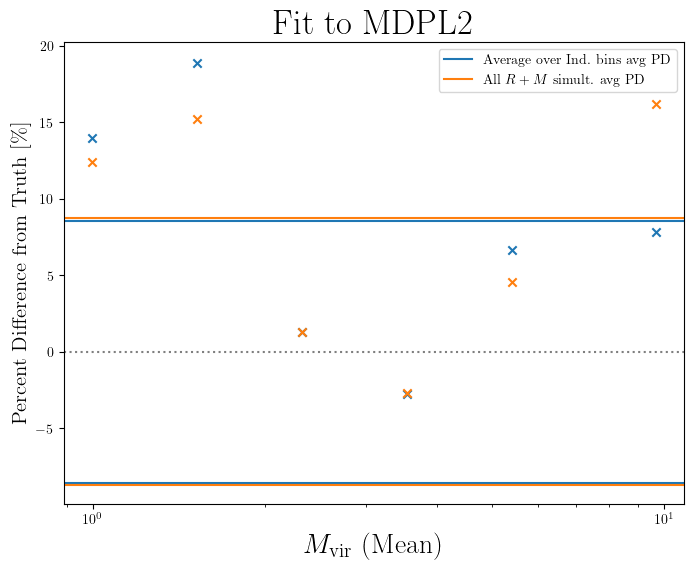

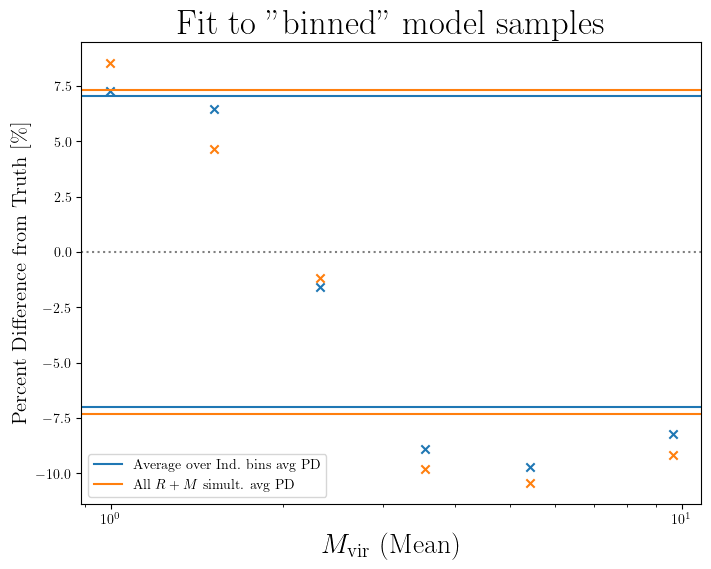

In [72]:
for j in range(len(LOS_hists)):
    fig, ax = plt.subplots(figsize=(8,6))

    ax.scatter(mmeans, ((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mmeans)/mmeans)*100, marker='x')
    ax.axhline(np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mmeans)/mmeans))*100, label=r'Average over Ind. bins avg PD') 
    ax.axhline(-np.mean(np.abs((np.mean(par_mass_ind[j, :, :, 0], axis=-1)-mmeans)/mmeans))*100 ) 


    #ax.scatter(mmeans, ((par_mass_ind[j, :, 0]-mmeans)/mmeans)*100, marker='x')
    #ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-mmeans)/mmeans))*100, label=r'All $R | M$', c='C1') 

    ax.scatter(mmeans, ((par_mass_sim[j]-mmeans)/mmeans)*100, marker='x')
    ax.axhline(np.mean(np.abs((par_mass_sim[j]-mmeans)/mmeans))*100, label=r'All $R+M$ simult. avg PD', c='C1') 
    ax.axhline(-np.mean(np.abs((par_mass_sim[j]-mmeans)/mmeans))*100, c='C1') 

    ax.axhline(0.0, c='k', ls=':', alpha=0.5)
    ax.set_xlabel(r"$M_{\rm vir}$ (Mean)", fontsize=20) 
    ax.set_ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
    ax.set_xscale('log')
    #ax.set_ylim((-5, 5))
    ax.set_title(titles[j], fontsize=25)
    ax.legend()